# Explainable Loan Default Risk Prediction Using Machine Learning

# I Overview
## 1.1 Executive Summary 

# II Business Understanding

## 2.1 Stakeholder

The Credit Risk Manager is responsible for assessing the creditworthiness of loan applicants and managing the company's lending risk. They make daily decisions regarding loan approvals, loan pricing, customer eligibility, and risk mitigation strategies to ensure sustainable lending operations.

This person needs to decide, for each loan application, whether to approve or reject it based on predicted risk of default.

---

## 2.2 Business Problem

How can a lending institution predict, before issuing a loan, which applicants are likely to default so that the institution can reduce financial losses while maintaining fair access to credit?

Without a prediction model, the institution must either reject all risky-looking applicants (losing potentially good customers) or approve too many applicants (accumulating bad debt and increasing financial losses).

---

## 2.3 Business Objectives

The primary objective is to reduce loan default rates by identifying high-risk borrowers before loan approval.

Specific objectives include:

* Improving the accuracy of credit risk assessment.
* Supporting faster and more consistent lending decisions.
* Reducing financial losses associated with customer defaults.
* Increasing access to credit for creditworthy customers.
* Enhancing the sustainability and profitability of lending operations.

---

## 2.4 Data Science Objectives

The data science objective is to develop and evaluate machine learning models capable of predicting whether a customer is likely to default on a loan.

Specific objectives include:

* Building predictive classification models using customer demographic, credit history, and repayment data.
* Comparing the performance of Logistic Regression, Random Forest, and XGBoost models.
* Identifying the most important drivers of loan default.
* Applying explainable AI techniques to improve transparency and stakeholder trust.
* Generating actionable insights to support credit risk management decisions.

---

## 2.5 Success Criteria

### Business Success Metrics

The model must identify at least 70% of actual defaulters. Missing a true defaulter can result in substantial financial losses due to unpaid loans.

The model should maintain a Precision of at least 0.60. Excessively flagging low-risk customers as risky may lead to lost business opportunities and reduced customer satisfaction.

The model should achieve an ROC-AUC score of at least 0.75, demonstrating meaningful predictive ability beyond random guessing.

These targets will be used later to evaluate whether the final model is suitable for supporting lending decisions.

---

## 2.6 Business Understanding

## 2.6.1 Stakeholder

The Credit Risk Manager at M-KOPA Kenya is responsible for assessing the creditworthiness of loan applicants and managing the company's lending risk. They make daily decisions regarding loan approvals, loan pricing, customer eligibility, and risk mitigation strategies to ensure sustainable lending operations.

This person needs to decide, for each loan application, whether to approve or reject it based on predicted risk of default.

---

## 2.6.2 Business Problem

How can a Kenyan lending institution predict, before issuing a loan, which applicants are likely to default so that the institution can reduce financial losses while maintaining fair access to credit?

Without a prediction model, the institution must either reject all risky-looking applicants (losing potentially good customers) or approve too many applicants (accumulating bad debt and increasing financial losses).

---

## 2.6.3 Business Objectives

The primary objective is to reduce loan default rates by identifying high-risk borrowers before loan approval.

Specific objectives include:

* Improving the accuracy of credit risk assessment.
* Supporting faster and more consistent lending decisions.
* Reducing financial losses associated with customer defaults.
* Increasing access to credit for creditworthy customers.
* Enhancing the sustainability and profitability of lending operations.

---

## 2.6.4 Data Science Objectives

The data science objective is to develop and evaluate machine learning models capable of predicting whether a customer is likely to default on a loan.

Specific objectives include:

* Building predictive classification models using customer demographic, credit history, and repayment data.
* Comparing the performance of Logistic Regression, Random Forest, and XGBoost models.
* Identifying the most important drivers of loan default.
* Applying explainable AI techniques to improve transparency and stakeholder trust.
* Generating actionable insights to support credit risk management decisions.

---

## 2.7 Success Criteria

### Business Success Metrics


The model must identify at least 70% of actual defaulters (Recall ≥ 0.70). Missing a true defaulter can result in substantial financial losses due to unpaid loans.

The model should maintain a Precision of at least 0.60. Excessively flagging low-risk customers as risky may lead to lost business opportunities and reduced customer satisfaction.

The model should achieve an ROC-AUC score of at least 0.75, demonstrating meaningful predictive ability beyond random guessing.

These targets will be used later to evaluate whether the final model is suitable for supporting lending decisions.

---

## 2.8 Kenyan Context and Project Relevance


Digital lending plays a significant role in Kenya's financial sector, with organizations such as M-KOPA, Tala, Branch, and major banks using data-driven credit assessment to serve millions of customers. As lending grows, accurate and explainable credit risk models are essential for reducing defaults while promoting financial inclusion.

Although this project uses data from Home Credit's Eastern European operations, the methodology is directly applicable to Kenyan digital lending. The techniques used to predict default risk and explain lending decisions are highly relevant to modern credit scoring systems in Kenya.



# III Data Understanding

## 3.1 Dataset Description

The Home Credit Default Risk dataset consists of multiple related tables containing customer information, credit history, previous applications, repayment behavior, and credit card activity. These datasets will be combined to create a customer-level dataset for predicting loan default risk.

### application_train.csv

The primary dataset containing one record per loan application. It includes customer demographic and financial information as well as the target variable (`TARGET`), where 1 indicates default and 0 indicates successful repayment.

**Join Key:** `SK_ID_CURR`

### bureau.csv

Contains the applicant's credit history from other financial institutions reported to the credit bureau. Since multiple records may exist per customer, aggregation is required before merging.

**Join Key:** `SK_ID_CURR`

### previous_application.csv

Contains records of all previous loan applications submitted to Home Credit. It provides insights into past borrowing behavior and lending decisions.

**Join Keys:** `SK_ID_CURR`, `SK_ID_PREV`

### installments_payments.csv

Contains repayment history for previous Home Credit loans, including payment timing and amounts. This dataset helps assess repayment discipline and must be aggregated before merging.

**Join Key:** `SK_ID_PREV`

### credit_card_balance.csv

Contains monthly credit card balance snapshots, including credit utilization and outstanding balances. It provides insights into how customers manage revolving credit.

**Join Key:** `SK_ID_CURR`

### Relational Structure

The analysis will use `application_train.csv` as the master dataset. Additional customer-level features will be created by aggregating and merging information from the other datasets using `SK_ID_CURR` and `SK_ID_PREV`.


## 3.2 Data Understanding
#### Loading the Home Credit CSV files in a portable, and repeatable. This ensures that file paths are managed centrally, making the notebook more organized, reusable, and portable across different environments.

In [1]:
# Setting DATA_DIR and file path helper
# import libraries
from pathlib import Path

import pandas as pd
from IPython.display import Markdown, display

# set data directory
# Update this path to the folder that contains your Home Credit CSV files.
DATA_DIR = Path(r"C:\Users\Kim\Desktop\Loan Default Predictions")


# helper function to build file paths
def data_path(filename: str) -> Path:
    """Build a portable path to a file in the data directory."""
    return DATA_DIR / filename


DATA_DIR

WindowsPath('C:/Users/Kim/Desktop/Loan Default Predictions')

In [2]:
# Loading each  file (datasets) with pd.read_csv()
# helper function to inspect each loaded dataset
def print_load_check(name: str, df: pd.DataFrame, target_column: str | None = None) -> None:
    print(f"{name}: shape = {df.shape}")
    display(df.head(3))

    if target_column is not None:
        print(f"{name}: {target_column} distribution")
        display(
            df[target_column]
            .value_counts(normalize=True)
            .rename("proportion")
            .mul(100)
            .round(2)
            .to_frame()
        )


# load main training file
application_train = pd.read_csv(data_path("application_train.csv"))
print_load_check("application_train", application_train, target_column="TARGET")

# load bureau history
bureau = pd.read_csv(data_path("bureau.csv"))
print_load_check("bureau", bureau)

# load previous applications
previous_application = pd.read_csv(data_path("previous_application.csv"))
print_load_check("previous_application", previous_application)

# load installment payment history
installments_payments = pd.read_csv(data_path("installments_payments.csv"))
print_load_check("installments_payments", installments_payments)

# load credit card balance history
credit_card_balance = pd.read_csv(data_path("credit_card_balance.csv"))
print_load_check("credit_card_balance", credit_card_balance)

application_train: shape = (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


application_train: TARGET distribution


,proportion
TARGET,
0,91.93
1,8.07


bureau: shape = (1716428, 17)


...

,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,...,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,...,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,...,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0


installments_payments: shape = (13605401, 8)


,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_VERSION,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT
0,1054186,161674,1.0,6,-1180.0,-1187.0,6948.360,6948.360
1,1330831,151639,0.0,34,-2156.0,-2156.0,1716.525,1716.525
2,2085231,193053,2.0,1,-63.0,-63.0,25425.000,25425.000


credit_card_balance: shape = (3840312, 23)


,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL,AMT_DRAWINGS_ATM_CURRENT,AMT_DRAWINGS_CURRENT,AMT_DRAWINGS_OTHER_CURRENT,AMT_DRAWINGS_POS_CURRENT,AMT_INST_MIN_REGULARITY,...,AMT_RECIVABLE,AMT_TOTAL_RECEIVABLE,CNT_DRAWINGS_ATM_CURRENT,CNT_DRAWINGS_CURRENT,CNT_DRAWINGS_OTHER_CURRENT,CNT_DRAWINGS_POS_CURRENT,CNT_INSTALMENT_MATURE_CUM,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,2562384,378907,-6,56.970,135000,0.0,877.5,0.0,877.5,1700.325,...,0.000,0.000,0.0,1,0.0,1.0,35.0,Active,0,0
1,2582071,363914,-1,63975.555,45000,2250.0,2250.0,0.0,0.0,2250.000,...,64875.555,64875.555,1.0,1,0.0,0.0,69.0,Active,0,0
2,1740877,371185,-7,31815.225,450000,0.0,0.0,0.0,0.0,2250.000,...,31460.085,31460.085,0.0,0,0.0,0.0,30.0,Active,0,0


In [3]:
# Summaries of each file
#print("application_train summary:")
#display(application_train.describe(include="all").T)
#print("bureau summary:")
#display(bureau.describe(include="all").T)
#print("previous_application summary:")
#display(previous_application.describe(include="all").T)
#print("installments_payments summary:")
#display(installments_payments.describe(include="all").T)
#print("credit_card_balance summary:")
#display(credit_card_balance.describe(include="all").T)

In [4]:
# Creating a summary table of the datasets
# creating a dictionary of loaded datasets
datasets = {
    "application_train": application_train,
    "bureau": bureau,
    "previous_application": previous_application,
    "installments_payments": installments_payments,
    "credit_card_balance": credit_card_balance,
}

# build summary table for quick data quality overview
summary_table = pd.DataFrame(
    [
        {
            "dataset": name,
            "rows": df.shape[0],
            "columns": df.shape[1],
            "missing_pct": df.isna().mean().mean() * 100,
        }
        for name, df in datasets.items()
    ]
).assign(missing_pct=lambda frame: frame["missing_pct"].round(2))

display(summary_table)

,dataset,rows,columns,missing_pct
0,application_train,307511,122,24.40
1,bureau,1716428,17,13.50
2,previous_application,1670214,37,17.98
3,installments_payments,13605401,8,0.01
4,credit_card_balance,3840312,23,6.65


### Loading column descriptions and create a lookup helper

In [5]:
#  Loading column descriptions and create a lookup helper
# load column descriptions file if available
description_path = data_path("HomeCredit_columns_description.csv")

if description_path.exists():
    columns_description = pd.read_csv(description_path, encoding="latin1")
    print_load_check("HomeCredit_columns_description", columns_description)
else:
    columns_description = pd.DataFrame(columns=["Table", "Row", "Description"])
    print(f"Column descriptions file not found: {description_path}")
    print("Add HomeCredit_columns_description.csv to DATA_DIR before using describe_column().")


# helper function to explain unfamiliar columns
def describe_column(column_name: str) -> None:
    """Print the Home Credit data dictionary description for a column."""
    matches = columns_description[
        columns_description["Row"].astype(str).str.casefold() == column_name.casefold()
    ]

    if matches.empty:
        print(f"No description found for {column_name!r}.")
        return

    display(matches[["Table", "Row", "Description"]].drop_duplicates())


if not columns_description.empty:
    describe_column("TARGET")

Column descriptions file not found: C:\Users\Kim\Desktop\Loan Default Predictions\HomeCredit_columns_description.csv
Add HomeCredit_columns_description.csv to DATA_DIR before using describe_column().


### Interpretation 

In [6]:
# Interpretation of the main training file and target variable
# write interpretation using values from the loaded data
applicant_count = len(application_train)
default_rate = application_train["TARGET"].mean() * 100

display(
    Markdown(
        f"The main training file contains {applicant_count:,} applicants with an "
        f"{default_rate:.0f}% default rate. Multiple auxiliary files provide "
        "historical financial behaviour at the individual level."
    )
)

The main training file contains 307,511 applicants with an 8% default rate. Multiple auxiliary files provide historical financial behaviour at the individual level.

### 3.3 Data Merging
The source datasets contain multiple records per customer, while `application_train` contains one record per loan applicant. To avoid creating duplicate customer records during merging, each dataset must first be aggregated into a customer-level summary.

This process is applied to `bureau.csv`, `previous_application.csv`, `installments_payments.csv`, and `credit_card_balance.csv` before they are merged with the main application dataset.

In [7]:
# aggregate bureau data to one row per applicant
bureau_features = bureau.assign(
    is_active_loan=(bureau["CREDIT_ACTIVE"] == "Active").astype(int),
    has_bad_debt=(bureau["CREDIT_ACTIVE"] == "Bad debt").astype(int),
).groupby("SK_ID_CURR").agg(
    bureau_total_loan_count=("SK_ID_BUREAU", "count"),
    bureau_active_loan_count=("is_active_loan", "sum"),
    bureau_max_overdue_days=("CREDIT_DAY_OVERDUE", "max"),
    bureau_mean_overdue_days=("CREDIT_DAY_OVERDUE", "mean"),
    bureau_total_outstanding_debt=("AMT_CREDIT_SUM_DEBT", "sum"),
    bureau_total_credit_limit=("AMT_CREDIT_SUM_LIMIT", "sum"),
    bureau_any_bad_debt_history=("has_bad_debt", "max"),
).reset_index()

print(f"bureau_features shape = {bureau_features.shape}")
display(bureau_features.head())

bureau_features shape = (305811, 8)


,SK_ID_CURR,bureau_total_loan_count,bureau_active_loan_count,bureau_max_overdue_days,bureau_mean_overdue_days,bureau_total_outstanding_debt,bureau_total_credit_limit,bureau_any_bad_debt_history
0,100001,7,3,0,0.0,596686.5,0.000,0
1,100002,8,2,0,0.0,245781.0,31988.565,0
2,100003,4,1,0,0.0,0.0,810000.000,0
3,100004,2,0,0,0.0,0.0,0.000,0
4,100005,3,2,0,0.0,568408.5,0.000,0


In [8]:
# aggregate previous applications to one row per applicant
previous_features = previous_application.assign(
    is_approved=(previous_application["NAME_CONTRACT_STATUS"] == "Approved").astype(int),
    is_refused=(previous_application["NAME_CONTRACT_STATUS"] == "Refused").astype(int),
).groupby("SK_ID_CURR").agg(
    previous_total_application_count=("SK_ID_PREV", "count"),
    previous_approved_count=("is_approved", "sum"),
    previous_refused_count=("is_refused", "sum"),
    previous_avg_amount_applied=("AMT_APPLICATION", "mean"),
    previous_avg_amount_approved=("AMT_CREDIT", "mean"),
    previous_most_recent_application_days=("DAYS_DECISION", "max"),
).reset_index()

previous_features["previous_approval_rate"] = (
    previous_features["previous_approved_count"]
    / previous_features["previous_total_application_count"]
)

print(f"previous_features shape = {previous_features.shape}")
display(previous_features.head())

previous_features shape = (338857, 8)


,SK_ID_CURR,previous_total_application_count,previous_approved_count,previous_refused_count,previous_avg_amount_applied,previous_avg_amount_approved,previous_most_recent_application_days,previous_approval_rate
0,100001,1,1,0,24835.50,23787.00,-1740,1.0
1,100002,1,1,0,179055.00,179055.00,-606,1.0
2,100003,3,3,0,435436.50,484191.00,-746,1.0
3,100004,1,1,0,24282.00,20106.00,-815,1.0
4,100005,2,1,0,22308.75,20076.75,-315,0.5


In [9]:
# create payment lateness features before aggregation
installments_with_features = installments_payments.assign(
    DAYS_LATE=installments_payments["DAYS_ENTRY_PAYMENT"] - installments_payments["DAYS_INSTALMENT"],
    is_late=lambda df: (df["DAYS_LATE"] > 0).astype(int),
    payment_ratio=lambda df: df["AMT_PAYMENT"] / df["AMT_INSTALMENT"].where(df["AMT_INSTALMENT"] != 0),
)

# aggregate installment payments to one row per applicant
installments_features = installments_with_features.groupby("SK_ID_CURR").agg(
    installments_max_days_late_ever=("DAYS_LATE", "max"),
    installments_mean_days_late=("DAYS_LATE", "mean"),
    installments_late_payment_count=("is_late", "sum"),
    installments_late_payment_pct=("is_late", "mean"),
    installments_avg_payment_ratio=("payment_ratio", "mean"),
).reset_index()

print(f"installments_features shape = {installments_features.shape}")
display(installments_features.head())

installments_features shape = (339587, 6)


,SK_ID_CURR,installments_max_days_late_ever,installments_mean_days_late,installments_late_payment_count,installments_late_payment_pct,installments_avg_payment_ratio
0,100001,11.0,-7.285714,1,0.142857,1.0
1,100002,-12.0,-20.421053,0,0.000000,1.0
2,100003,-1.0,-7.160000,0,0.000000,1.0
3,100004,-3.0,-7.666667,0,0.000000,1.0
4,100005,1.0,-23.555556,1,0.111111,1.0


In [10]:
# create credit card behaviour features before aggregation
credit_card_with_features = credit_card_balance.assign(
    is_overdue=(credit_card_balance["SK_DPD"] > 0).astype(int),
    credit_utilisation=lambda df: df["AMT_BALANCE"] / df["AMT_CREDIT_LIMIT_ACTUAL"].where(df["AMT_CREDIT_LIMIT_ACTUAL"] != 0),
)

# aggregate credit card history to one row per applicant
credit_card_features = credit_card_with_features.groupby("SK_ID_CURR").agg(
    credit_card_months_of_history=("MONTHS_BALANCE", "nunique"),
    credit_card_max_days_past_due=("SK_DPD", "max"),
    credit_card_mean_balance=("AMT_BALANCE", "mean"),
    credit_card_mean_credit_limit=("AMT_CREDIT_LIMIT_ACTUAL", "mean"),
    credit_card_months_overdue=("is_overdue", "sum"),
    credit_card_utilisation_ratio=("credit_utilisation", "mean"),
).reset_index()

print(f"credit_card_features shape = {credit_card_features.shape}")
display(credit_card_features.head())

credit_card_features shape = (103558, 7)


,SK_ID_CURR,credit_card_months_of_history,credit_card_max_days_past_due,credit_card_mean_balance,credit_card_mean_credit_limit,credit_card_months_overdue,credit_card_utilisation_ratio
0,100006,6,0,0.000000,270000.000000,0,0.000000
1,100011,74,0,54482.111149,164189.189189,0,0.302678
2,100013,96,1,18159.919219,131718.750000,1,0.115301
3,100021,17,0,0.000000,675000.000000,0,0.000000
4,100023,8,0,0.000000,135000.000000,0,0.000000


### Merging Applicant-Level Features

The aggregated feature tables are merged with `application_train` using a **LEFT JOIN** on `SK_ID_CURR`. A LEFT JOIN ensures that all applicants remain in the dataset, including those without bureau records or previous credit history.

Using an INNER JOIN would remove applicants with missing historical records, potentially introducing selection bias and reducing the representativeness of the final dataset.

In [11]:
# merging all aggregated features onto the main training file
merged_train = application_train.copy()
print(f"starting shape = {merged_train.shape}")

feature_tables = [
    ("bureau_features", bureau_features),
    ("previous_features", previous_features),
    ("installments_features", installments_features),
    ("credit_card_features", credit_card_features),
]

# left join one feature table at a time and print shape after each merge
for table_name, feature_table in feature_tables:
    merged_train = merged_train.merge(feature_table, on="SK_ID_CURR", how="left")
    print(f"after left joining {table_name}: {merged_train.shape}")

assert len(merged_train) == len(application_train), "LEFT JOIN should keep all training applicants."
display(merged_train.head())

starting shape = (307511, 122)
after left joining bureau_features: (307511, 129)
after left joining previous_features: (307511, 136)
after left joining installments_features: (307511, 141)
after left joining credit_card_features: (307511, 147)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,installments_mean_days_late,installments_late_payment_count,installments_late_payment_pct,installments_avg_payment_ratio,credit_card_months_of_history,credit_card_max_days_past_due,credit_card_mean_balance,credit_card_mean_credit_limit,credit_card_months_overdue,credit_card_utilisation_ratio
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,-20.421053,0.0,0.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,-7.160000,0.0,0.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,-7.666667,0.0,0.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,-19.375000,0.0,0.000000,1.000000,6.0,0.0,0.0,270000.0,0.0,0.0
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,-3.636364,16.0,0.242424,0.954545,NaN,NaN,NaN,NaN,NaN,NaN


### Interpretation after merging

In [12]:
# Interpretation after merging
display(
    Markdown(
        f"The merged dataset contains {len(merged_train):,} applicants with "
        f"{merged_train.shape[1]:,} total features. Applicants with no external "
        "credit history have NaN values in bureau columns - this is expected "
        "and will be handled by imputation."
    )
)

The merged dataset contains 307,511 applicants with 147 total features. Applicants with no external credit history have NaN values in bureau columns - this is expected and will be handled by imputation.

### 3.4 Dataset Overview

The merged dataset contains **307,511 loan applicants** and **147 features**. Each row represents a unique applicant, while the columns capture demographic, financial, and credit-related information used for risk assessment.

Some applicants do not have records in the credit bureau dataset, resulting in missing (`NaN`) values in bureau-related features. This is expected and indicates that no external credit history was available for those applicants, rather than a data quality issue.

These missing values will be addressed during the data preparation phase through appropriate imputation techniques, ensuring that applicants without external credit history remain available for analysis and model development.

## 3.5 Data Cleaning

### Loading Libraries and Dataset
Setting `DATA_PATH` to the raw CSV file location.  
The dataset is loaded and copied into `cleaned_df` to allow cleaning and transformations while keeping the original `df` unchanged.

In [13]:
# import libraries
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Markdown, display

# helper function to build file paths
def data_path(filename: str) -> Path:
    return DATA_DIR / filename


# load the main training dataset
df = pd.read_csv(data_path("application_train.csv"))
print(f"original shape = {df.shape}")
display(df.head())

original shape = (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


### Dropping high-missing columns

In [14]:
# calculate missing percentage for every column
missing_pct = df.isna().mean().mul(100).sort_values(ascending=False)

# identify and drop columns with more than 60% missing values
high_missing_cols = missing_pct[missing_pct > 60].index.tolist()
df_clean = df.drop(columns=high_missing_cols)

print(f"columns dropped = {len(high_missing_cols)}")
print("dropped columns:")
print(high_missing_cols)
print(f"shape after dropping high-missing columns = {df_clean.shape}")

columns dropped = 17
dropped columns:
['COMMONAREA_AVG', 'COMMONAREA_MODE', 'COMMONAREA_MEDI', 'NONLIVINGAPARTMENTS_MEDI', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAPARTMENTS_AVG', 'FONDKAPREMONT_MODE', 'LIVINGAPARTMENTS_AVG', 'LIVINGAPARTMENTS_MEDI', 'LIVINGAPARTMENTS_MODE', 'FLOORSMIN_MODE', 'FLOORSMIN_AVG', 'FLOORSMIN_MEDI', 'YEARS_BUILD_AVG', 'YEARS_BUILD_MODE', 'YEARS_BUILD_MEDI', 'OWN_CAR_AGE']
shape after dropping high-missing columns = (307511, 105)


### Fixing the DAYS_EMPLOYED anomaly
The value 365243 in DAYS_EMPLOYED means "unemployed or pensioner". It is not a real employment duration, so it should be flagged before replacing it with missing values.

In [15]:
# flagging the known DAYS_EMPLOYED anomaly before replacing it
employed_anom_mask = df_clean["DAYS_EMPLOYED"] == 365243
employed_anom_count = int(employed_anom_mask.sum())
employed_anom_pct = employed_anom_mask.mean() * 100

df_clean["EMPLOYED_ANOM"] = employed_anom_mask.astype(int)
df_clean.loc[employed_anom_mask, "DAYS_EMPLOYED"] = np.nan

print(f"records affected = {employed_anom_count:,}")
print(f"percentage affected = {employed_anom_pct:.2f}%")

records affected = 55,374
percentage affected = 18.01%


### Converting negative day columns to positive years
DAYS_BIRTH, DAYS_EMPLOYED, DAYS_REGISTRATION, and DAYS_ID_PUBLISH are stored as negative days. Converting them to positive years makes the columns easier to interpret.

In [16]:
# converting negative day counts into positive year-based features
day_to_year_features = {
    "DAYS_BIRTH": "AGE_YEARS",
    "DAYS_EMPLOYED": "EMPLOYMENT_YEARS",
    "DAYS_REGISTRATION": "REGISTRATION_YEARS",
    "DAYS_ID_PUBLISH": "ID_PUBLISH_YEARS",
}

for source_col, new_col in day_to_year_features.items():
    df_clean[new_col] = df_clean[source_col] / -365.25

display(df_clean[list(day_to_year_features.values())].head())

,AGE_YEARS,EMPLOYMENT_YEARS,REGISTRATION_YEARS,ID_PUBLISH_YEARS
0,25.902806,1.744011,9.987680,5.804244
1,45.900068,3.252567,3.247091,0.796715
2,52.145106,0.616016,11.663244,6.929500
3,52.032854,8.320329,26.921287,6.672142
4,54.570842,8.317591,11.802875,9.467488


### Handling outliers
For AMT_INCOME_TOTAL, values near 100M+ are almost certainly data entry errors. Capping at the 99th percentile keeps extreme values from dominating the model.

In [17]:
# caping income at the 99th percentile
income_cap = df_clean["AMT_INCOME_TOTAL"].quantile(0.99)
income_outlier_mask = df_clean["AMT_INCOME_TOTAL"] > income_cap
income_outlier_count = int(income_outlier_mask.sum())

df_clean.loc[income_outlier_mask, "AMT_INCOME_TOTAL"] = income_cap

print(f"99th percentile income cap = {income_cap:,.2f}")
print(f"records capped = {income_outlier_count:,}")

99th percentile income cap = 472,500.00
records capped = 3,014


### Identifying column types
Separating numerical and categorical columns is used directly in preprocessing pipelines.

In [18]:
# separate columns by data type for preprocessing pipelines
numerical_cols = df_clean.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()
categorical_cols = df_clean.select_dtypes(include=["object", "string", "category"]).columns.tolist()

print(f"number of numerical columns = {len(numerical_cols)}")
print(f"number of categorical columns = {len(categorical_cols)}")

print("sample numerical columns:")
print(numerical_cols[:10])

print("sample categorical columns:")
print(categorical_cols[:10])

number of numerical columns = 95
number of categorical columns = 15
sample numerical columns:
['SK_ID_CURR', 'TARGET', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED']
sample categorical columns:
['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE']


### Final shape checking

In [19]:
# final cleaned dataset shape
print(f"final cleaned shape = {df_clean.shape}")

# print missing value counts again after cleaning
final_missing_counts = df_clean.isna().sum().sort_values(ascending=False)
final_missing_counts = final_missing_counts[final_missing_counts > 0]

print(f"columns still containing missing values = {len(final_missing_counts)}")
display(final_missing_counts.to_frame("missing_count").head(30))

# interpretation after shape and missing-value checks
display(
    Markdown(
        f"After cleaning, the dataset contains {df_clean.shape[1]:,} columns. "
        "Remaining missing values in numerical columns will be handled by "
        "median imputation in the pipeline."
    )
)

final cleaned shape = (307511, 110)
columns still containing missing values = 52


,missing_count
LANDAREA_MODE,182590
LANDAREA_AVG,182590
LANDAREA_MEDI,182590
BASEMENTAREA_MODE,179943
BASEMENTAREA_AVG,179943
BASEMENTAREA_MEDI,179943
EXT_SOURCE_1,173378
NONLIVINGAREA_AVG,169682
NONLIVINGAREA_MEDI,169682
NONLIVINGAREA_MODE,169682


After cleaning, the dataset contains 110 columns. Remaining missing values in numerical columns will be handled by median imputation in the pipeline.

### Interpretation after cleaning

In [20]:
# final interpretation of cleaning decisions
display(
    Markdown(
        f"The cleaning process removed {len(high_missing_cols):,} low-information columns. "
        f"The DAYS_EMPLOYED anomaly affected {employed_anom_pct:.2f}% of applicants "
        "and has been flagged as a separate feature, preserving its predictive signal."
    )
)

The cleaning process removed 17 low-information columns. The DAYS_EMPLOYED anomaly affected 18.01% of applicants and has been flagged as a separate feature, preserving its predictive signal.

# 3.6 Feature Engineering

The next step is creating six credit-risk features using domain knowledge from lending, affordability analysis, and historical repayment behavior. Each feature is being designed to capture meaningful patterns, explain how it is calculated, and improve predictive performance for repayment outcomes.

In [21]:
# import libraries
from pathlib import Path

import numpy as np
import pandas as pd

# helper function to build file paths
def data_path(filename: str) -> Path:
    return DATA_DIR / filename


# helper function for safe division
def safe_divide(numerator: pd.Series, denominator: pd.Series) -> pd.Series:
    return numerator / denominator.where(denominator != 0)


# load required datasets
application_train = pd.read_csv(data_path("application_train.csv"))
installments_payments = pd.read_csv(data_path("installments_payments.csv"))

# create a working feature engineering dataframe
features_df = application_train.copy()

print(f"application_train shape = {application_train.shape}")
print(f"installments_payments shape = {installments_payments.shape}")

application_train shape = (307511, 122)
installments_payments shape = (13605401, 8)


###  `DEBT_TO_INCOME`

This feature is measuring the relationship between the total loan amount and annual income to capture borrower affordability. It is being calculated as `AMT_CREDIT / AMT_INCOME_TOTAL`, providing a ratio that reflects how large the requested loan is relative to earnings.

This feature is considered predictive because it is a widely used credit-risk affordability measure. Borrowers requesting loans that are several times larger than annual income are often financially stretched and may have less flexibility to handle income disruptions. A ratio above `3.5` is generally being treated as high risk since the loan burden becomes significantly large compared to income.

In [22]:
# create debt-to-income feature
features_df["DEBT_TO_INCOME"] = safe_divide(
    features_df["AMT_CREDIT"],
    features_df["AMT_INCOME_TOTAL"],
)

# optional high-risk flag based on the 3.5 threshold
features_df["HIGH_DEBT_TO_INCOME"] = (features_df["DEBT_TO_INCOME"] > 3.5).astype(int)

print(features_df["DEBT_TO_INCOME"].describe())
print(f"share above 3.5 = {features_df['HIGH_DEBT_TO_INCOME'].mean() * 100:.2f}%")

count    307511.000000
mean          3.957570
std           2.689728
min           0.004808
25%           2.018667
50%           3.265067
75%           5.159880
max          84.736842
Name: DEBT_TO_INCOME, dtype: float64
share above 3.5 = 45.70%


### `ANNUITY_TO_INCOME`

This feature is measuring the monthly repayment burden as a proportion of annual income to better understand repayment affordability. It is being calculated as `AMT_ANNUITY / AMT_INCOME_TOTAL`, capturing the share of income required to meet scheduled loan repayments.

This feature is considered predictive because the total loan amount alone does not indicate whether repayments are manageable. Instead, this ratio is directly measuring repayment pressure. A value above `30%` is generally being treated as high risk, since a substantial portion of income is already being allocated to debt servicing.

In [23]:
# create annuity-to-income feature
features_df["ANNUITY_TO_INCOME"] = safe_divide(
    features_df["AMT_ANNUITY"],
    features_df["AMT_INCOME_TOTAL"],
)

# optional high-risk flag based on the 30% threshold
features_df["HIGH_ANNUITY_TO_INCOME"] = (features_df["ANNUITY_TO_INCOME"] > 0.30).astype(int)

print(features_df["ANNUITY_TO_INCOME"].describe())
print(f"share above 30% = {features_df['HIGH_ANNUITY_TO_INCOME'].mean() * 100:.2f}%")

count    307499.000000
mean          0.180930
std           0.094574
min           0.000224
25%           0.114782
50%           0.162833
75%           0.229067
max           1.875965
Name: ANNUITY_TO_INCOME, dtype: float64
share above 30% = 10.18%


### `CREDIT_TO_GOODS`

This feature is measuring the relationship between the loan amount and the value of the goods being purchased. It is being calculated as `AMT_CREDIT / AMT_GOODS_PRICE`, showing whether the borrowed amount aligns with the cost of the purchased asset.

This feature is considered predictive because a ratio above `1.0` suggests that the applicant is borrowing more than the goods are worth. This may indicate additional financing needs beyond the purchase itself, such as covering extra costs or cash shortages, which can signal potential financial stress.

In [24]:
# create credit-to-goods feature
features_df["CREDIT_TO_GOODS"] = safe_divide(
    features_df["AMT_CREDIT"],
    features_df["AMT_GOODS_PRICE"],
)

# optional flag for borrowing more than the goods price
features_df["BORROWED_ABOVE_GOODS_VALUE"] = (features_df["CREDIT_TO_GOODS"] > 1.0).astype(int)

print(features_df["CREDIT_TO_GOODS"].describe())
print(f"share above 1.0 = {features_df['BORROWED_ABOVE_GOODS_VALUE'].mean() * 100:.2f}%")

count    307233.000000
mean          1.122995
std           0.124045
min           0.150000
25%           1.000000
50%           1.118800
75%           1.198000
max           6.000000
Name: CREDIT_TO_GOODS, dtype: float64
share above 1.0 = 64.64%


### `PAYMENT_RATE`

This feature is measuring the scheduled repayment amount relative to the total loan amount to estimate repayment speed. It is being calculated as `AMT_ANNUITY / AMT_CREDIT`, reflecting how much of the loan is expected to be repaid over time.

This feature is considered predictive because it approximates how quickly the applicant is repaying the loan. A higher payment rate is usually indicating a shorter loan term, which may reduce overall credit risk since the borrower is being exposed to fewer months of future financial uncertainty.

In [25]:
# create payment-rate feature
features_df["PAYMENT_RATE"] = safe_divide(
    features_df["AMT_ANNUITY"],
    features_df["AMT_CREDIT"],
)

print(features_df["PAYMENT_RATE"].describe())

count    307499.000000
mean          0.053695
std           0.022481
min           0.022073
25%           0.036900
50%           0.050000
75%           0.064043
max           0.124430
Name: PAYMENT_RATE, dtype: float64


### `INCOME_PER_PERSON`

This feature is measuring household income after adjusting for the number of family members supported by that income. It is being calculated as `AMT_INCOME_TOTAL / CNT_FAM_MEMBERS`, providing a more realistic estimate of financial capacity at the household level.

This feature is considered predictive because the same total income can represent different repayment abilities depending on household size. A borrower supporting several family members is likely having less disposable income than someone with fewer dependents earning the same amount. As a result, income per person is often being considered more informative than total income alone when assessing repayment capacity.

In [26]:
# create income-per-person feature
features_df["INCOME_PER_PERSON"] = safe_divide(
    features_df["AMT_INCOME_TOTAL"],
    features_df["CNT_FAM_MEMBERS"],
)

print(features_df["INCOME_PER_PERSON"].describe())

count    3.075090e+05
mean     9.310588e+04
std      1.013734e+05
min      2.812500e+03
25%      4.725000e+04
50%      7.500000e+04
75%      1.125000e+05
max      3.900000e+07
Name: INCOME_PER_PERSON, dtype: float64


### `INST_PCT_LATE`

This feature is measuring the percentage of previous installment payments that were made late to capture historical repayment behavior. It is being calculated by first creating `DAYS_LATE = DAYS_ENTRY_PAYMENT - DAYS_INSTALMENT`, where a positive value indicates a late payment. The data is then being grouped by `SK_ID_CURR`, and the mean of the late-payment flag is calculated to estimate the proportion of missed deadlines.

This feature is considered predictive because it acts as a direct behavioral repayment signal. Historical payment behavior is often being viewed as one of the strongest indicators of future repayment performance, as it reflects financial discipline, cash-flow pressure, and the borrower’s ability or willingness to make payments on time.

In [27]:
# create late-payment indicator in installment history
installments_features = installments_payments.assign(
    DAYS_LATE=installments_payments["DAYS_ENTRY_PAYMENT"] - installments_payments["DAYS_INSTALMENT"],
    INST_IS_LATE=lambda df: (df["DAYS_LATE"] > 0).astype(int),
).groupby("SK_ID_CURR").agg(
    INST_PCT_LATE=("INST_IS_LATE", "mean"),
).reset_index()

# merge behavioral installment feature onto application-level data
features_df = features_df.merge(installments_features, on="SK_ID_CURR", how="left")

print(f"installments_features shape = {installments_features.shape}")
print(features_df["INST_PCT_LATE"].describe())
print(f"missing INST_PCT_LATE values = {features_df['INST_PCT_LATE'].isna().sum():,}")

installments_features shape = (339587, 2)
count    291643.000000
mean          0.075792
std           0.116030
min           0.000000
25%           0.000000
50%           0.018519
75%           0.111111
max           1.000000
Name: INST_PCT_LATE, dtype: float64
missing INST_PCT_LATE values = 15,868


### Feature Check

In [28]:
# review engineered features
engineered_features = [
    "DEBT_TO_INCOME",
    "ANNUITY_TO_INCOME",
    "CREDIT_TO_GOODS",
    "PAYMENT_RATE",
    "INCOME_PER_PERSON",
    "INST_PCT_LATE",
]

print(f"feature engineering dataframe shape = {features_df.shape}")
display(features_df[["SK_ID_CURR", "TARGET"] + engineered_features].head(10))
display(features_df[engineered_features].describe().T)

feature engineering dataframe shape = (307511, 131)


,SK_ID_CURR,TARGET,DEBT_TO_INCOME,ANNUITY_TO_INCOME,CREDIT_TO_GOODS,PAYMENT_RATE,INCOME_PER_PERSON,INST_PCT_LATE
0,100002,1,2.007889,0.121978,1.158397,0.060749,202500.0,0.000000
1,100003,0,4.790750,0.132217,1.145199,0.027598,135000.0,0.000000
2,100004,0,2.000000,0.100000,1.000000,0.050000,67500.0,0.000000
3,100006,0,2.316167,0.219900,1.052803,0.094941,67500.0,0.000000
4,100007,0,4.222222,0.179963,1.000000,0.042623,121500.0,0.242424
5,100008,0,4.954500,0.277955,1.079198,0.056101,49500.0,0.028571
6,100009,0,9.127053,0.241526,1.118800,0.026463,57000.0,0.019608
7,100010,0,4.250000,0.116875,1.000000,0.027500,180000.0,0.000000
8,100011,0,9.063200,0.300680,1.116158,0.033176,56250.0,0.146154
9,100012,0,3.000000,0.150000,1.000000,0.050000,135000.0,0.104167


,count,mean,std,min,25%,50%,75%,max
DEBT_TO_INCOME,307511.0,3.957570,2.689728,0.004808,2.018667,3.265067,5.159880,8.473684e+01
ANNUITY_TO_INCOME,307499.0,0.180930,0.094574,0.000224,0.114782,0.162833,0.229067,1.875965e+00
CREDIT_TO_GOODS,307233.0,1.122995,0.124045,0.150000,1.000000,1.118800,1.198000,6.000000e+00
PAYMENT_RATE,307499.0,0.053695,0.022481,0.022073,0.036900,0.050000,0.064043,1.244296e-01
INCOME_PER_PERSON,307509.0,93105.879645,101373.363394,2812.500000,47250.000000,75000.000000,112500.000000,3.900000e+07
INST_PCT_LATE,291643.0,0.075792,0.116030,0.000000,0.000000,0.018519,0.111111,1.000000e+00


# IV Exploratory Data Analysis EDA

### 
The next step is performing exploratory data analysis (EDA) to better understand the structure, patterns, and relationships within the dataset. Each visualization is being created to tell a clear story about borrower behavior and potential default risk.

Every chart is including a descriptive title, properly labeled axes, and a written interpretation explaining what the results are showing and why the observed patterns matter for predicting loan default.

In [29]:
# import libraries
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

# set chart style
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 6)

# helper function to build file paths
def data_path(filename: str) -> Path:
    return DATA_DIR / filename


# helper function for safe division
def safe_divide(numerator: pd.Series, denominator: pd.Series) -> pd.Series:
    return numerator / denominator.where(denominator != 0)


# load required datasets
application_train = pd.read_csv(data_path("application_train.csv"))
installments_payments = pd.read_csv(data_path("installments_payments.csv"))

# create working dataframe and engineered features needed for EDA
eda_df = application_train.copy()
eda_df["DEBT_TO_INCOME"] = safe_divide(eda_df["AMT_CREDIT"], eda_df["AMT_INCOME_TOTAL"])
eda_df["ANNUITY_TO_INCOME"] = safe_divide(eda_df["AMT_ANNUITY"], eda_df["AMT_INCOME_TOTAL"])
eda_df["AGE_YEARS"] = eda_df["DAYS_BIRTH"] / -365.25

# map target labels for clearer charts
target_labels = {0: "Repaid", 1: "Defaulted"}
eda_df["TARGET_LABEL"] = eda_df["TARGET"].map(target_labels)

print(f"application_train shape = {application_train.shape}")
print(f"installments_payments shape = {installments_payments.shape}")

application_train shape = (307511, 122)
installments_payments shape = (13605401, 8)


### 4.1 Target Distribution

C:\Users\Kim\AppData\Local\Temp\ipykernel_37268\1400395908.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_counts.index, y=target_counts.values, ax=axes[0], palette=["#2e7d32", "#c62828"])


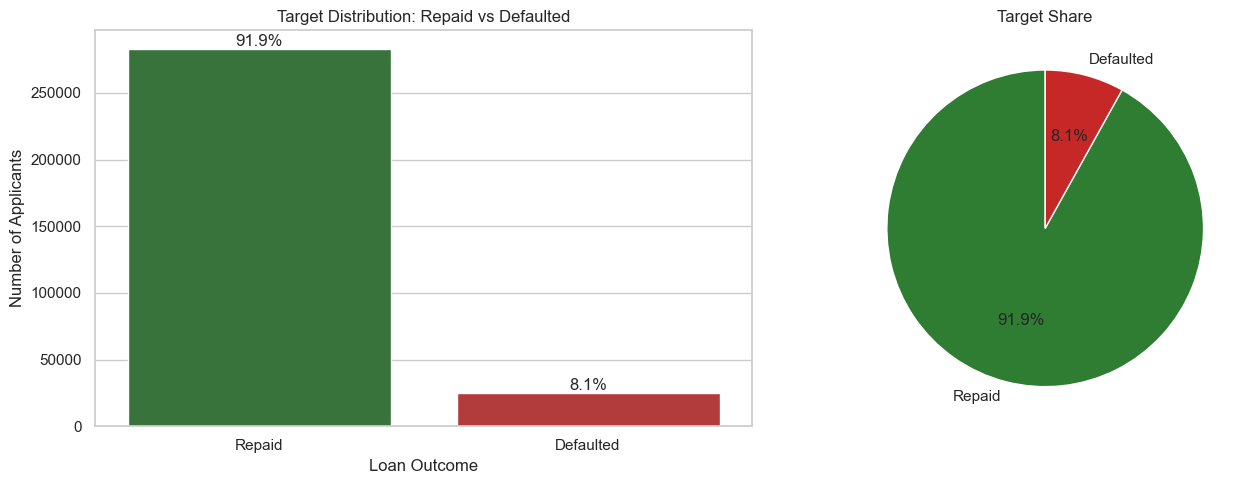

In [30]:
# chart 1: target distribution using bar chart and pie chart
target_counts = eda_df["TARGET_LABEL"].value_counts().reindex(["Repaid", "Defaulted"])
target_pct = target_counts / target_counts.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=target_counts.index, y=target_counts.values, ax=axes[0], palette=["#2e7d32", "#c62828"])
axes[0].set_title("Target Distribution: Repaid vs Defaulted")
axes[0].set_xlabel("Loan Outcome")
axes[0].set_ylabel("Number of Applicants")

for index, value in enumerate(target_counts.values):
    axes[0].text(index, value, f"{target_pct.iloc[index]:.1f}%", ha="center", va="bottom")

axes[1].pie(
    target_counts.values,
    labels=target_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#2e7d32", "#c62828"],
)
axes[1].set_title("Target Share")

plt.tight_layout()
plt.show()

##### This severe class imbalance (92/8) is the central challenge of this project. A naive model predicting 'all repaid' achieves 92% accuracy but catches zero defaulters. This is why we use SMOTE and report F1 Score and ROC-AUC rather than accuracy.

### 4.2 Missing Values Bar Chart

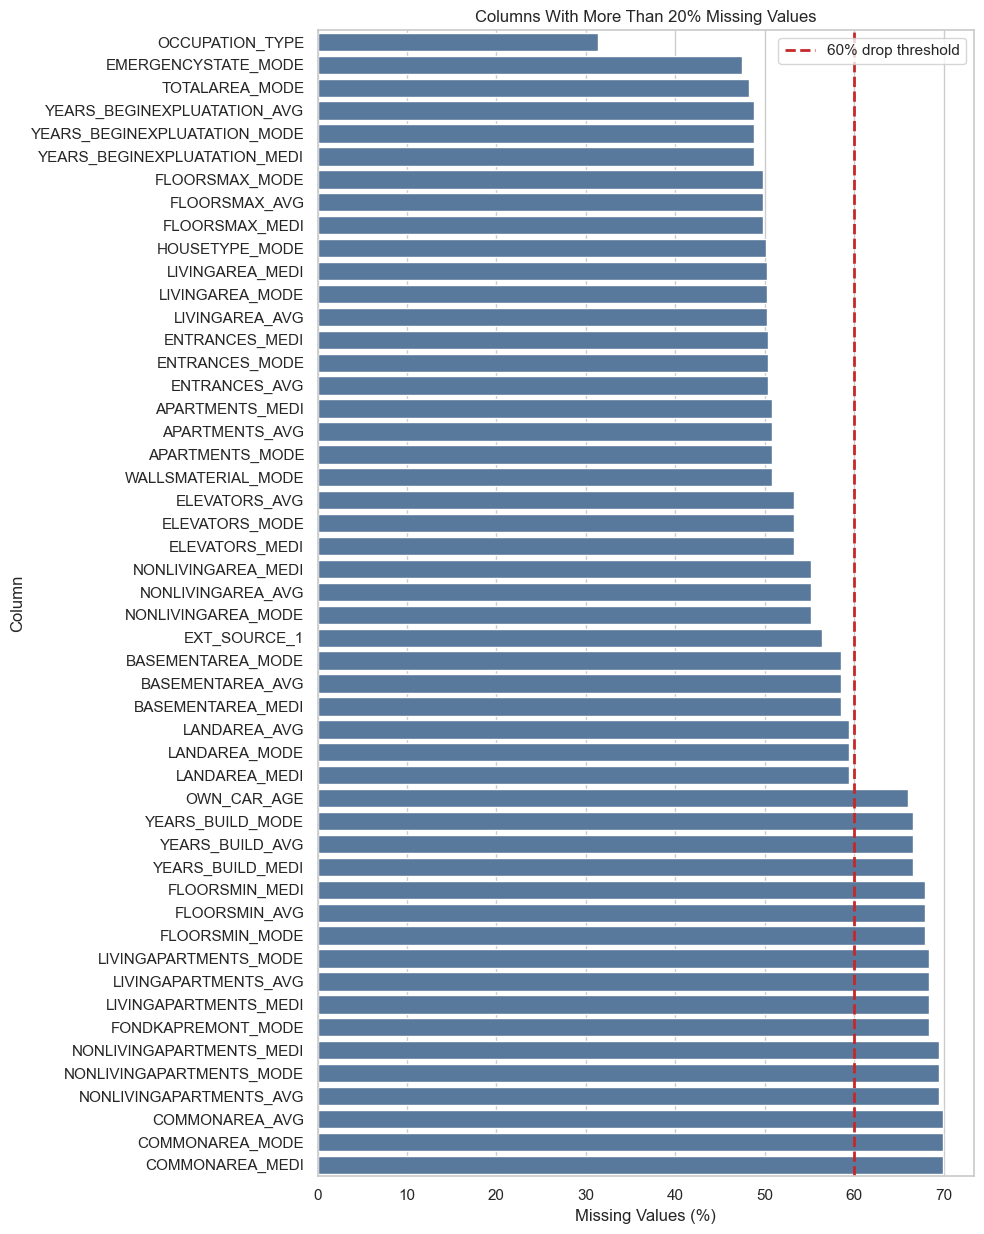

In [31]:
# chart 2: missing values above 20%, with 60% drop threshold
missing_pct = eda_df.drop(columns=["TARGET_LABEL"], errors="ignore").isna().mean().mul(100)
missing_over_20 = missing_pct[missing_pct > 20].sort_values(ascending=True)

plt.figure(figsize=(10, max(6, len(missing_over_20) * 0.25)))
sns.barplot(x=missing_over_20.values, y=missing_over_20.index, color="#4e79a7")
plt.axvline(60, color="#c62828", linestyle="--", linewidth=2, label="60% drop threshold")
plt.title("Columns With More Than 20% Missing Values")
plt.xlabel("Missing Values (%)")
plt.ylabel("Column")
plt.legend()
plt.tight_layout()
plt.show()

##### Columns above the 60% line will be dropped. Structural missingness is expected and not random.

#### 4.3 Feature Distributions (Defaulted vs Repaid)

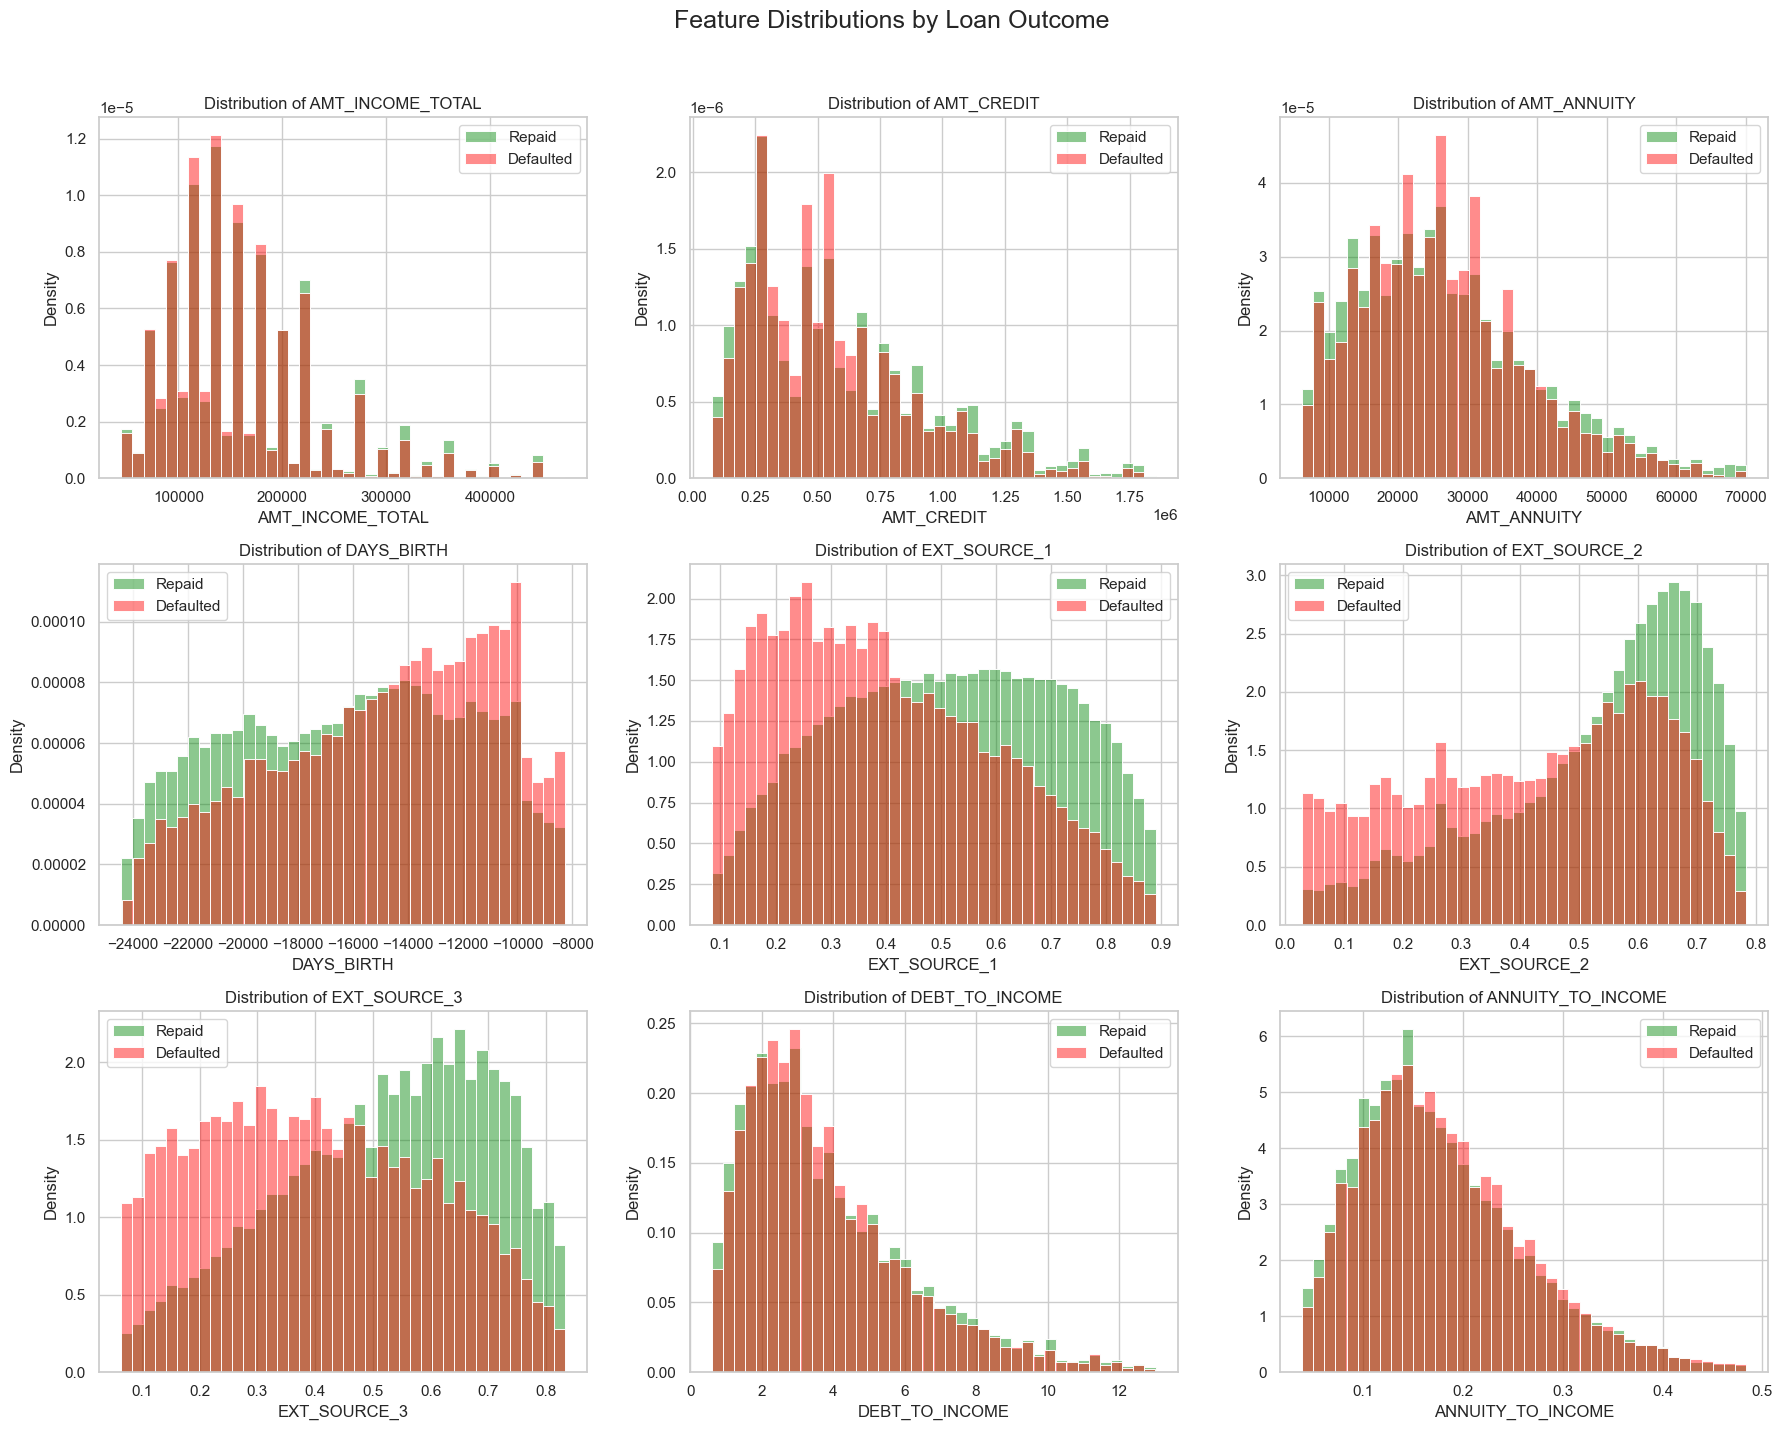

In [32]:
# chart 3: overlapping histograms for key numerical features
distribution_features = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "DAYS_BIRTH",
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
    "DEBT_TO_INCOME",
    "ANNUITY_TO_INCOME",
]

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for ax, feature in zip(axes, distribution_features):
    # cap extreme tails for readability without changing the underlying data
    plot_data = eda_df[[feature, "TARGET"]].dropna()
    lower = plot_data[feature].quantile(0.01)
    upper = plot_data[feature].quantile(0.99)
    plot_data = plot_data[plot_data[feature].between(lower, upper)]

    sns.histplot(
        data=plot_data[plot_data["TARGET"] == 0],
        x=feature,
        stat="density",
        bins=40,
        color="#008707",
        alpha=0.45,
        ax=ax,
        label="Repaid",
    )
    sns.histplot(
        data=plot_data[plot_data["TARGET"] == 1],
        x=feature,
        stat="density",
        bins=40,
        color="#ff0000",
        alpha=0.45,
        ax=ax,
        label="Defaulted",
    )
    ax.set_title(f"Distribution of {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Density")
    ax.legend()

fig.suptitle("Feature Distributions by Loan Outcome", fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

##### Features where the red and green distributions are separated are predictive. EXT_SOURCE_2 shows the clearest separation, applicants with low external credit scores are heavily over-represented among defaulters.

##### 4.4 Default Rate by Categorical Feature

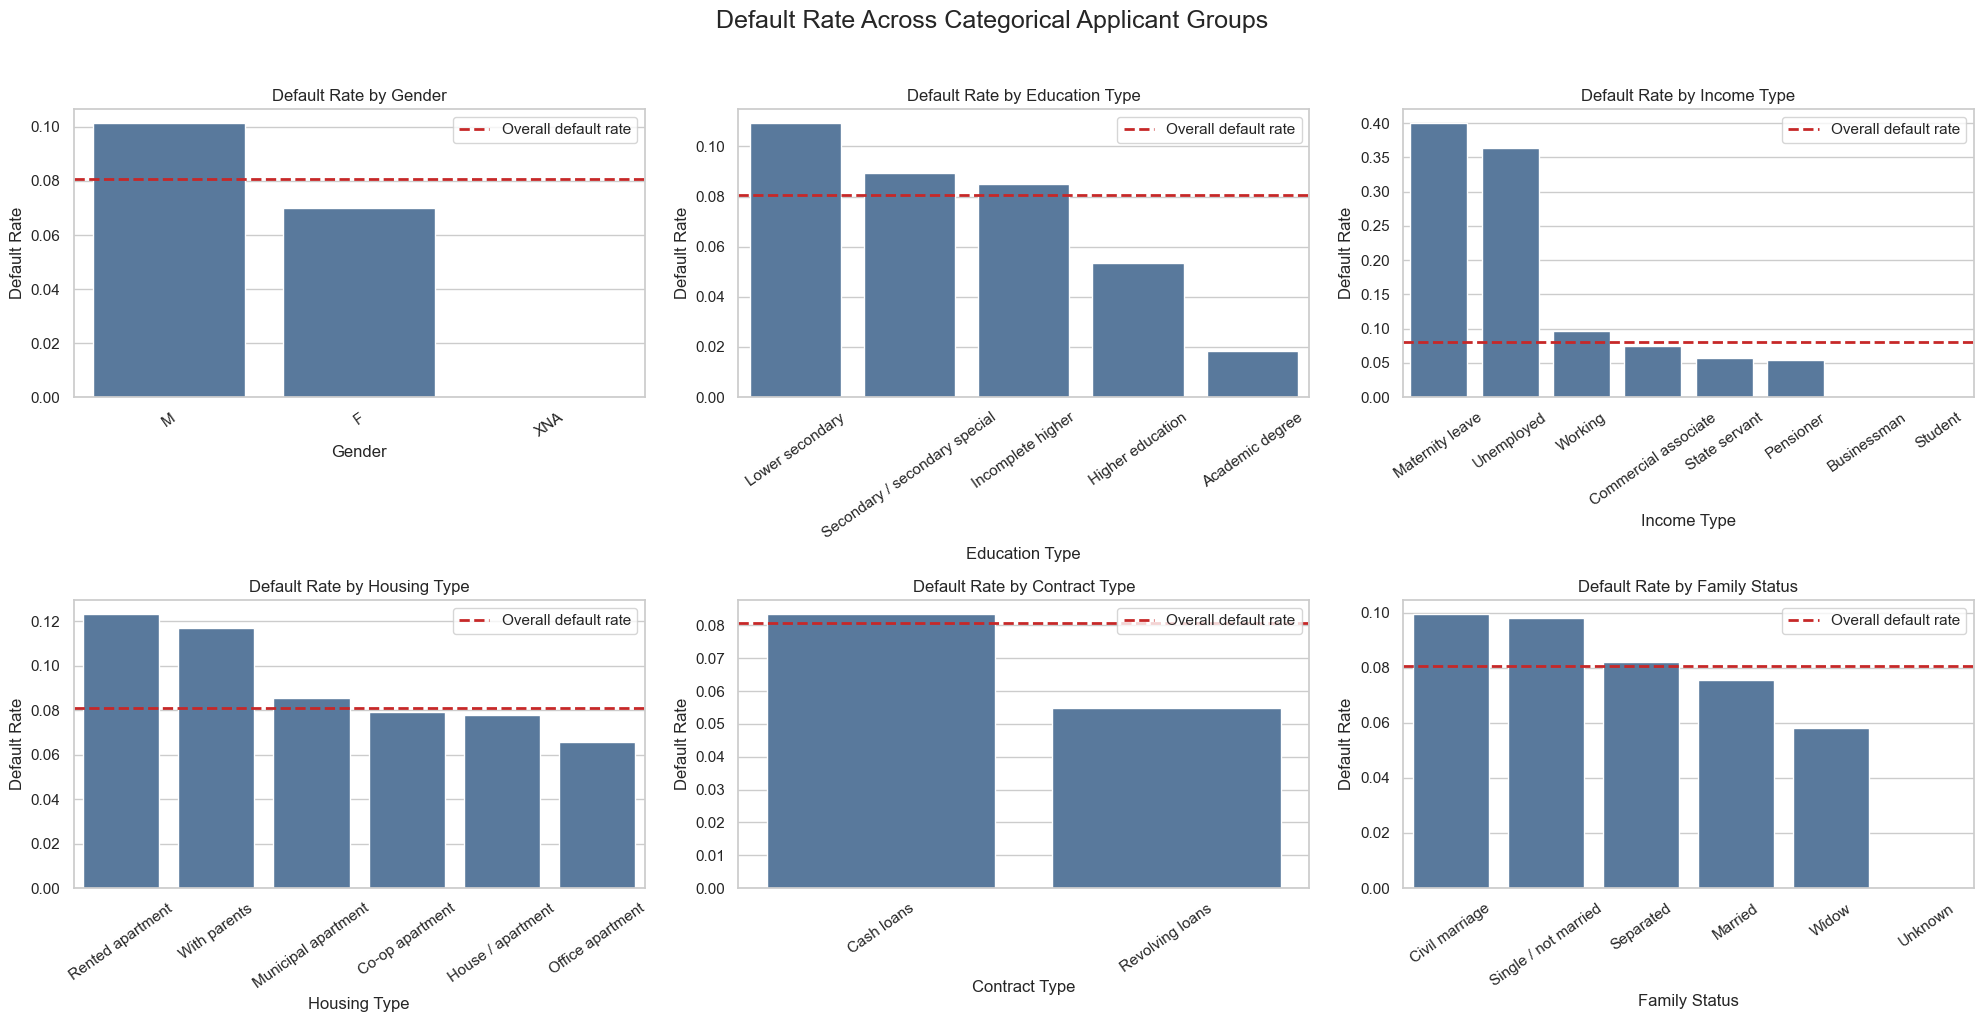

In [33]:
# chart 4: default rate by categorical feature
categorical_features = {
    "Gender": "CODE_GENDER",
    "Education Type": "NAME_EDUCATION_TYPE",
    "Income Type": "NAME_INCOME_TYPE",
    "Housing Type": "NAME_HOUSING_TYPE",
    "Contract Type": "NAME_CONTRACT_TYPE",
    "Family Status": "NAME_FAMILY_STATUS",
}

overall_default_rate = eda_df["TARGET"].mean()
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

for ax, (title, column) in zip(axes, categorical_features.items()):
    rate_table = (
        eda_df.groupby(column)["TARGET"]
        .mean()
        .sort_values(ascending=False)
        .reset_index()
    )

    sns.barplot(data=rate_table, x=column, y="TARGET", ax=ax, color="#4e79a7")
    ax.axhline(overall_default_rate, color="#c62828", linestyle="--", linewidth=2, label="Overall default rate")
    ax.set_title(f"Default Rate by {title}")
    ax.set_xlabel(title)
    ax.set_ylabel("Default Rate")
    ax.tick_params(axis="x", rotation=35)
    ax.legend()

fig.suptitle("Default Rate Across Categorical Applicant Groups", fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

##### Categories above the dashed line represent above-average risk. Unemployed applicants and those on maternity leave show default rates 2 to 3 times the average, groups requiring additional scrutiny.

#### 4.5 Age Group Default Rate

C:\Users\Kim\AppData\Local\Temp\ipykernel_37268\877729977.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=age_default_rate, x="AGE_GROUP", y="TARGET", palette=colors)


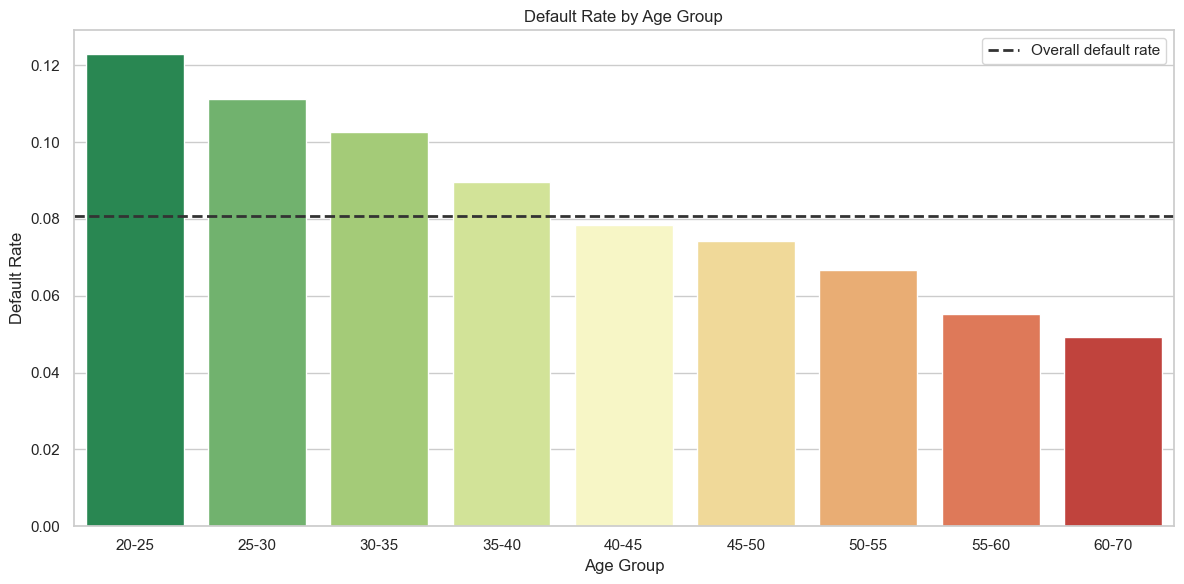

In [34]:
# chart 5: default rate by age group
age_bins = [20, 25, 30, 35, 40, 45, 50, 55, 60, 70]
age_labels = ["20-25", "25-30", "30-35", "35-40", "40-45", "45-50", "50-55", "55-60", "60-70"]
eda_df["AGE_GROUP"] = pd.cut(eda_df["AGE_YEARS"], bins=age_bins, labels=age_labels, include_lowest=True)

age_default_rate = eda_df.groupby("AGE_GROUP", observed=True)["TARGET"].mean().reset_index()
colors = sns.color_palette("RdYlGn_r", n_colors=len(age_default_rate))

plt.figure(figsize=(12, 6))
sns.barplot(data=age_default_rate, x="AGE_GROUP", y="TARGET", palette=colors)
plt.axhline(overall_default_rate, color="#333333", linestyle="--", linewidth=2, label="Overall default rate")
plt.title("Default Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Default Rate")
plt.legend()
plt.tight_layout()
plt.show()

##### The youngest applicants (20-25) default at nearly double the overall rate. Default risk decreases consistently with age. This confirms the well-established finding in credit risk literature that age is a proxy for financial stability and experience with debt management.

#### 4.6 Correlation with Target

C:\Users\Kim\AppData\Local\Temp\ipykernel_37268\1698366502.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_plot.values, y=corr_plot.index, palette=bar_colors)


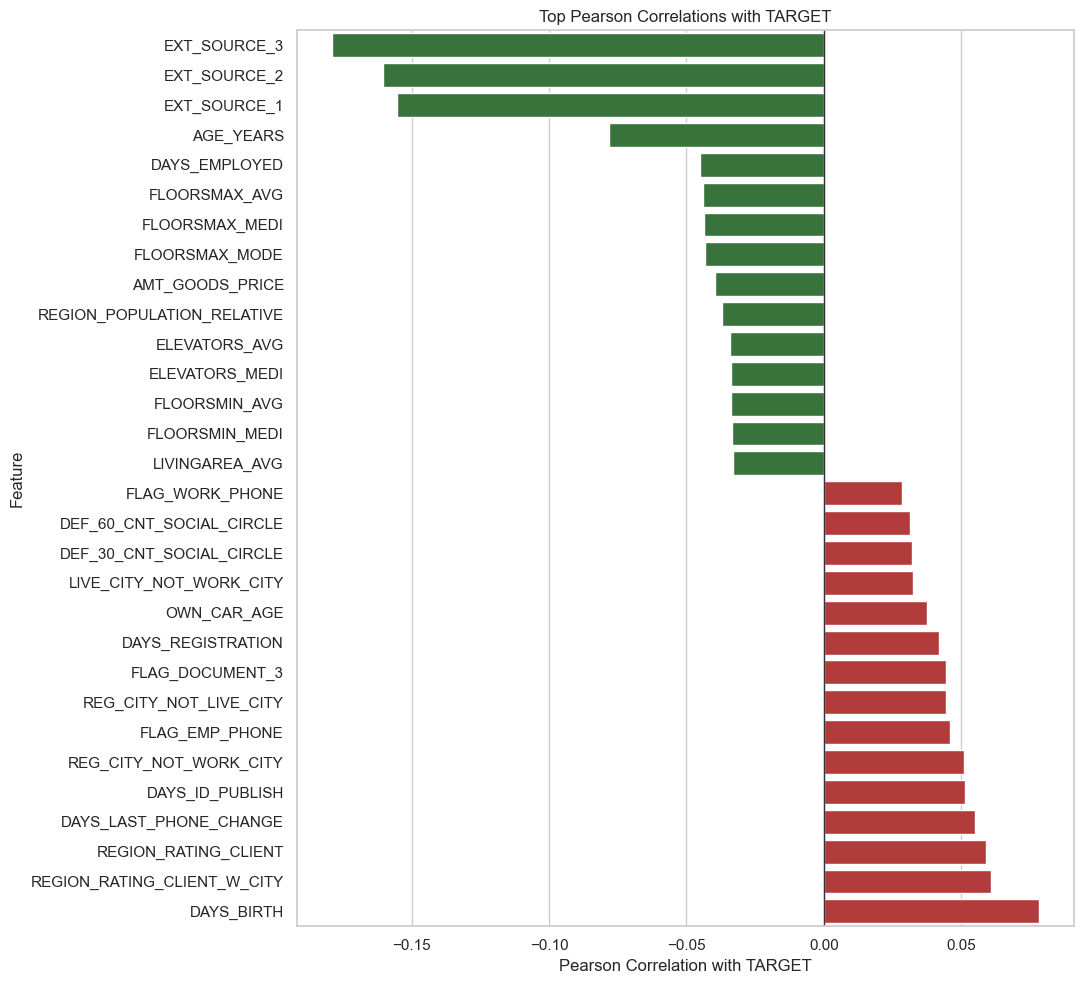

In [35]:
# chart 6: top positive and negative Pearson correlations with target
numeric_df = eda_df.select_dtypes(include=[np.number])
target_corr = numeric_df.corr(numeric_only=True)["TARGET"].drop("TARGET").dropna()

top_positive = target_corr.sort_values(ascending=False).head(15)
top_negative = target_corr.sort_values(ascending=True).head(15)
corr_plot = pd.concat([top_negative, top_positive]).sort_values()

bar_colors = ["#2e7d32" if value < 0 else "#c62828" for value in corr_plot.values]

plt.figure(figsize=(11, 10))
sns.barplot(x=corr_plot.values, y=corr_plot.index, palette=bar_colors)
plt.axvline(0, color="#333333", linewidth=1)
plt.title("Top Pearson Correlations with TARGET")
plt.xlabel("Pearson Correlation with TARGET")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

##### Correlation Analysis Interpretation

`EXT_SOURCE_2` and `EXT_SOURCE_3` are showing the strongest negative correlations with loan default, suggesting that higher external credit scores are strongly associated with lower default risk. These variables are likely contributing significant predictive power and may become some of the most influential features during model training.

It is important to note that Pearson correlation is only measuring linear relationships between variables. More complex, non-linear interactions that may not appear in the correlation matrix are expected to be captured by ensemble models such as `RandomForest` and `XGBoost`.

#### 4.7 Installment Payment Lateness

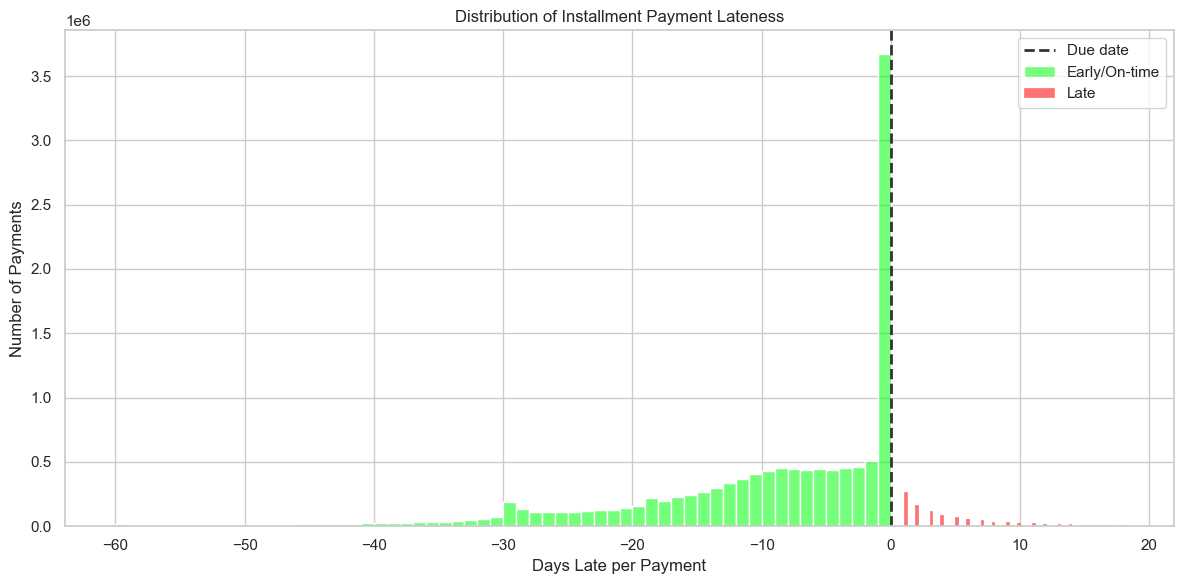

8.4% of all historical payments were made late. Maximum lateness reaches 2884 days. Applicants with chronic late payment patterns (>20% of all payments late) show significantly elevated default risk on new loans: 12.0% vs 7.6% for other applicants.

In [36]:
# chart 7: installment lateness distribution
installments_late = installments_payments.assign(
    DAYS_LATE=installments_payments["DAYS_ENTRY_PAYMENT"] - installments_payments["DAYS_INSTALMENT"],
    PAYMENT_STATUS=lambda df: np.where(df["DAYS_LATE"] > 0, "Late", "Early/On-time"),
)

late_pct = (installments_late["DAYS_LATE"] > 0).mean() * 100
max_lateness = installments_late["DAYS_LATE"].max()

# limit display range to keep the histogram readable
lower_bound = installments_late["DAYS_LATE"].quantile(0.01)
upper_bound = installments_late["DAYS_LATE"].quantile(0.99)
plot_late = installments_late[installments_late["DAYS_LATE"].between(lower_bound, upper_bound)]

plt.figure(figsize=(12, 6))
sns.histplot(
    data=plot_late[plot_late["PAYMENT_STATUS"] == "Early/On-time"],
    x="DAYS_LATE",
    bins=60,
    color="#00ff0d",
    alpha=0.55,
    label="Early/On-time",
)
sns.histplot(
    data=plot_late[plot_late["PAYMENT_STATUS"] == "Late"],
    x="DAYS_LATE",
    bins=60,
    color="#fa0000",
    alpha=0.55,
    label="Late",
)
plt.axvline(0, color="#333333", linestyle="--", linewidth=2, label="Due date")
plt.title("Distribution of Installment Payment Lateness")
plt.xlabel("Days Late per Payment")
plt.ylabel("Number of Payments")
plt.legend()
plt.tight_layout()
plt.show()

# compare default rates for applicants with chronic late-payment patterns
applicant_lateness = installments_late.groupby("SK_ID_CURR").agg(
    INST_PCT_LATE=("DAYS_LATE", lambda values: (values > 0).mean()),
).reset_index()
applicant_lateness = applicant_lateness.merge(eda_df[["SK_ID_CURR", "TARGET"]], on="SK_ID_CURR", how="inner")

chronic_late_default_rate = applicant_lateness.loc[applicant_lateness["INST_PCT_LATE"] > 0.20, "TARGET"].mean() * 100
non_chronic_default_rate = applicant_lateness.loc[applicant_lateness["INST_PCT_LATE"] <= 0.20, "TARGET"].mean() * 100

display(
    Markdown(
        f"{late_pct:.1f}% of all historical payments were made late. "
        f"Maximum lateness reaches {max_lateness:.0f} days. Applicants with chronic late payment patterns "
        f"(>20% of all payments late) show significantly elevated default risk on new loans: "
        f"{chronic_late_default_rate:.1f}% vs {non_chronic_default_rate:.1f}% for other applicants."
    )
)

# V Modeling

#### 5.1 Train/Test Split → Preprocessing → Modelling → Tuning

The next stage is building the machine learning pipeline, starting with splitting the dataset into training and testing sets to ensure model performance is evaluated on unseen data. Preprocessing is then being applied to prepare the features for modelling, followed by training, evaluation, and hyperparameter tuning.

Each model is being presented in its own section with a clear explanation of why it was selected, the implementation code, and a written interpretation of the results to explain performance and relevance for loan default prediction.

### Train-Test Split

The dataset is being split into `80%` training data and `20%` testing data **before any preprocessing steps are applied**. This order is being followed to prevent **data leakage**, a critical issue where information from the test set unintentionally influences the training process.

Data leakage is one of the most common critical mistakes in predictive modelling because it can produce overly optimistic model performance. For example, calculating imputation values such as the mean on the full dataset before splitting would expose the model to information from the test set. As a result, evaluation metrics may appear stronger than they truly are, reducing the reliability of the model on unseen data.

In [37]:
# import libraries
from pathlib import Path

import pandas as pd
from sklearn.model_selection import train_test_split

# helper function to build file paths
def data_path(filename: str) -> Path:
    return DATA_DIR / filename


# load the main training file
application_train = pd.read_csv(data_path("application_train.csv"))

# separate features from the target before splitting
X = application_train.drop(columns=["TARGET"])
y = application_train["TARGET"]

# split BEFORE preprocessing to prevent data leakage
# stratify=y preserves the 92/8 class ratio in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

# print the shape of each split
print(f"X_train shape = {X_train.shape}")
print(f"X_test shape = {X_test.shape}")
print(f"y_train shape = {y_train.shape}")
print(f"y_test shape = {y_test.shape}")

# verify that stratification preserved the same default rate in both halves
overall_default_rate = y.mean() * 100
train_default_rate = y_train.mean() * 100
test_default_rate = y_test.mean() * 100

print(f"overall default rate = {overall_default_rate:.2f}%")
print(f"training default rate = {train_default_rate:.2f}%")
print(f"test default rate = {test_default_rate:.2f}%")

X_train shape = (246008, 121)
X_test shape = (61503, 121)
y_train shape = (246008,)
y_test shape = (61503,)
overall default rate = 8.07%
training default rate = 8.07%
test default rate = 8.07%


### 5.2 Preprocessing Pipelines — Why and How

Preprocessing pipelines are being implemented using `scikit-learn` Pipelines to organize and automate the sequence of data preparation steps before modelling. This approach is helping ensure consistency, reproducibility, and protection against common preprocessing errors.

The pipeline is ensuring that the imputer and scaler are being fitted **only on the training data**, preventing information from the test set from influencing the learning process. It is also applying the exact same transformations consistently to the test data, ensuring both datasets are processed identically. In addition, the pipeline is reducing the risk of errors by enforcing the correct order of preprocessing steps throughout the modelling workflow.

In [38]:
!pip install imbalanced-learn


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: C:\Users\Kim\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [39]:
# import libraries
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# set chart style
sns.set_theme(style="whitegrid")


# helper function to build file paths
def data_path(filename: str) -> Path:
    return DATA_DIR / filename


# helper function for safe division
def safe_divide(numerator: pd.Series, denominator: pd.Series) -> pd.Series:
    return numerator / denominator.where(denominator != 0)


# load required datasets
application_train = pd.read_csv(data_path("application_train.csv"))
installments_payments = pd.read_csv(data_path("installments_payments.csv"))

print(f"application_train shape = {application_train.shape}")
print(f"installments_payments shape = {installments_payments.shape}")

application_train shape = (307511, 122)
installments_payments shape = (13605401, 8)


## Prepare Modeling Dataset

This is preparing the modeling dataset by applying the earlier data cleaning and feature engineering steps before model training begins. This setup is keeping the workflow self-contained, ensuring that all transformations are consistently applied within the notebook prior to building the preprocessing pipelines.

In [41]:
# start from the main training dataset
model_df = application_train.copy()

# drop columns with more than 60% missing values
missing_pct = model_df.isna().mean().mul(100)
high_missing_cols = missing_pct[missing_pct > 60].index.tolist()
model_df = model_df.drop(columns=high_missing_cols)
print(f"dropped high-missing columns = {len(high_missing_cols)}")

# flag and replace the DAYS_EMPLOYED anomaly
employed_anom_mask = model_df["DAYS_EMPLOYED"] == 365243
model_df["EMPLOYED_ANOM"] = employed_anom_mask.astype(int)
model_df.loc[employed_anom_mask, "DAYS_EMPLOYED"] = np.nan

# create interpretable day-based features
model_df["AGE_YEARS"] = model_df["DAYS_BIRTH"] / -365.25
model_df["EMPLOYMENT_YEARS"] = model_df["DAYS_EMPLOYED"] / -365.25
model_df["REGISTRATION_YEARS"] = model_df["DAYS_REGISTRATION"] / -365.25
model_df["ID_PUBLISH_YEARS"] = model_df["DAYS_ID_PUBLISH"] / -365.25

# cap income at the 99th percentile
income_cap = model_df["AMT_INCOME_TOTAL"].quantile(0.99)
model_df["AMT_INCOME_TOTAL"] = model_df["AMT_INCOME_TOTAL"].clip(upper=income_cap)

# create engineered affordability features
model_df["DEBT_TO_INCOME"] = safe_divide(model_df["AMT_CREDIT"], model_df["AMT_INCOME_TOTAL"])
model_df["ANNUITY_TO_INCOME"] = safe_divide(model_df["AMT_ANNUITY"], model_df["AMT_INCOME_TOTAL"])
model_df["CREDIT_TO_GOODS"] = safe_divide(model_df["AMT_CREDIT"], model_df["AMT_GOODS_PRICE"])
model_df["PAYMENT_RATE"] = safe_divide(model_df["AMT_ANNUITY"], model_df["AMT_CREDIT"])
model_df["INCOME_PER_PERSON"] = safe_divide(model_df["AMT_INCOME_TOTAL"], model_df["CNT_FAM_MEMBERS"])

# create installment lateness feature and merge it into the modeling dataset
installments_features = installments_payments.assign(
    DAYS_LATE=installments_payments["DAYS_ENTRY_PAYMENT"] - installments_payments["DAYS_INSTALMENT"],
    INST_IS_LATE=lambda df: (df["DAYS_LATE"] > 0).astype(int),
).groupby("SK_ID_CURR").agg(
    INST_PCT_LATE=("INST_IS_LATE", "mean"),
).reset_index()

model_df = model_df.merge(installments_features, on="SK_ID_CURR", how="left")

print(f"model_df shape = {model_df.shape}")

dropped high-missing columns = 17
model_df shape = (307511, 116)


### 5.3 Numerical Pipeline

The numerical preprocessing pipeline is being used to prepare continuous variables for modelling by handling missing values and standardizing feature scales.

**Step 1:** `SimpleImputer(strategy='median')` is being applied to fill missing numerical values using the median. The median is being preferred over the mean because variables such as `AMT_INCOME_TOTAL` contain extreme outliers that could heavily distort average values, making the mean less reliable for imputation.

**Step 2:** `StandardScaler()` is being used to standardize numerical features so that values have a mean of `0` and a standard deviation of `1`. Scaling is important because models such as `LogisticRegression` are sensitive to feature magnitude. Without scaling, variables with very large values, such as income, may dominate smaller-scale variables such as age, reducing model balance and performance.

In [42]:
# identify numerical columns from the training set only
numerical_cols = X_train.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()

# build numerical preprocessing pipeline
numerical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

print(f"number of numerical columns = {len(numerical_cols)}")

number of numerical columns = 105


### Categorical Pipeline

The categorical preprocessing pipeline is being used to prepare non-numerical variables for modelling by handling missing values and converting categories into a machine-readable format.

**Step 1:** `SimpleImputer(strategy='most_frequent')` is being applied to fill missing categorical values using the most commonly occurring category. This approach is helping preserve the dominant pattern within each feature while avoiding data loss from missing values.

**Step 2:** `OneHotEncoder(handle_unknown='ignore')` is being used to convert categorical values into binary `0/1` columns, allowing machine learning models to process non-numeric information.

The parameter `handle_unknown='ignore'` is being included to ensure stability during prediction. Since the test set may contain category values that were not present in the training data, this setting is preventing errors by encoding unseen categories as all zeros instead of causing the pipeline to fail.

In [43]:
# identify categorical columns from the training set only
categorical_cols = X_train.select_dtypes(include=["object", "string", "category"]).columns.tolist()

# build a dense one-hot encoder so SMOTE can work after preprocessing
try:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    one_hot_encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

# build categorical preprocessing pipeline
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", one_hot_encoder),
    ]
)

print(f"number of categorical columns = {len(categorical_cols)}")

number of categorical columns = 16


### `ColumnTransformer`

`ColumnTransformer` is being used to combine both preprocessing pipelines into a single workflow. It is applying the numerical pipeline to numerical features and the categorical pipeline to categorical features simultaneously.

This approach is helping ensure that each feature type receives the correct preprocessing steps while keeping the workflow organized and reproducible. By combining both pipelines into one transformer, preprocessing is being applied consistently during both training and testing without requiring separate manual steps.

In [44]:
# combine numerical and categorical pipelines into one preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_pipeline, numerical_cols),
        ("cat", categorical_pipeline, categorical_cols),
    ]
)

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['SK_ID_CURR', 'CNT_CHILDREN',
                                  'AMT_INCOME_TOTAL', 'AMT_CREDIT',
                                  'AMT_ANNUITY', 'AMT_GOODS_PRICE',
                                  'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH',
                                  'DAYS_EMPLOYED', 'DAYS_REGISTRATION',
                                  'DAYS_ID_PUBLISH', 'OWN_CAR_AGE',
                                  'FLAG_MOBIL', 'FLA...
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['NAME_CONTRACT_TYPE', 'CODE_GENDER',
                                  'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
                                  'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE',
                                  'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS',
                                  'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE',
                                  'WEEKDAY_APPR_PROCESS_START',
                                  'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE',
                                  'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE',
                                  'EMERGENCYSTATE_MODE'])])

### Baseline Model — `LogisticRegression`

`LogisticRegression` is being used as the baseline machine learning model and the primary reference point for evaluating performance. It is one of the simplest classification algorithms, using a linear decision boundary to separate classes.

This model is being selected because it provides a strong benchmark for comparison. If performance is strong, simpler linear relationships may be sufficient for predicting loan default. However, if results are weak, this may indicate that the data contains more complex, non-linear patterns, suggesting that more advanced models may be necessary.

### Why `SMOTE`?

`SMOTE` (Synthetic Minority Oversampling Technique) is being used to address class imbalance by generating synthetic examples of the minority class during training. Instead of duplicating existing default cases, `SMOTE` is creating new synthetic observations by interpolating between existing minority samples.

This approach is helping the model learn meaningful default patterns without simply memorizing the training data. By improving representation of the minority class, the model is becoming better equipped to identify potential loan defaults.

Importantly, `SMOTE` is being applied **only to the training data** and never to the test set. This ensures that model evaluation remains realistic and prevents information leakage that could artificially inflate performance metrics.

In [45]:
# build baseline logistic regression model inside an imbalanced-learn pipeline
logistic_pipeline = ImbPipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("smote", SMOTE(sampling_strategy=0.3, random_state=42)),
        (
            "model",
            LogisticRegression(
                class_weight="balanced",
                C=0.1,
                max_iter=1000,
                random_state=42,
            ),
        ),
    ]
)

# train only on the training data
logistic_pipeline.fit(X_train, y_train)

# evaluate on the untouched test set
logistic_preds = logistic_pipeline.predict(X_test)
logistic_proba = logistic_pipeline.predict_proba(X_test)[:, 1]

print("Logistic Regression Classification Report")
print(classification_report(y_test, logistic_preds))
print(f"Logistic Regression ROC-AUC = {roc_auc_score(y_test, logistic_proba):.4f}")

C:\Users\Kim\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Kim\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  F

Logistic Regression Classification Report
              precision    recall  f1-score   support

           0       0.96      0.69      0.81     56538
           1       0.16      0.67      0.26      4965

    accuracy                           0.69     61503
   macro avg       0.56      0.68      0.53     61503
weighted avg       0.90      0.69      0.76     61503

Logistic Regression ROC-AUC = 0.7456


### Why `LogisticRegression`?

`LogisticRegression` is also being selected because of its interpretability. The model coefficients are showing both the direction and relative magnitude of each feature’s influence on loan default prediction.

This interpretability is making it easier to understand which variables are increasing or reducing default risk, providing transparency into model behavior. In addition, this characteristic is helping satisfy the project requirement for model interpretability by offering clear insight into feature importance and decision patterns.

### 5.4 RandomForest Model

`RandomForest` is being used as a non-linear ensemble model to improve predictive performance beyond the baseline `LogisticRegression` model. Instead of relying on a single decision tree, the model is building `200` independent decision trees, each trained on a random subset of the data and features. The final prediction is being determined through majority voting across all trees.

This ensemble approach is helping reduce overfitting while capturing complex, non-linear relationships in the data that simpler linear models may fail to identify. Since loan default behavior is often influenced by interactions between variables, `RandomForest` is providing a more flexible modelling approach.

**Key Parameters**

- `n_estimators=200`: The model is building `200` trees, allowing multiple predictions to contribute to the final decision through majority voting.

- `max_depth=10`: Tree depth is being restricted to prevent branches from growing excessively deep and memorizing training data, helping improve generalization.

- `min_samples_leaf=50`: Each terminal leaf is being required to contain at least `50` applicants, reducing the risk of creating highly specific patterns that may overfit the training set.

- `max_features='sqrt'`: Each tree is being trained on the square root of the available features, helping decorrelate trees and strengthen ensemble performance by increasing model diversity.

In [46]:
# build random forest model inside an imbalanced-learn pipeline
random_forest_pipeline = ImbPipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("smote", SMOTE(sampling_strategy=0.3, random_state=42)),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                max_depth=10,
                min_samples_leaf=50,
                max_features="sqrt",
                class_weight="balanced",
                n_jobs=-1,
                random_state=42,
            ),
        ),
    ]
)

# train only on the training data
random_forest_pipeline.fit(X_train, y_train)

# evaluate on the untouched test set
rf_preds = random_forest_pipeline.predict(X_test)
rf_proba = random_forest_pipeline.predict_proba(X_test)[:, 1]

print("Random Forest Classification Report")
print(classification_report(y_test, rf_preds))
print(f"Random Forest ROC-AUC = {roc_auc_score(y_test, rf_proba):.4f}")

Random Forest Classification Report
              precision    recall  f1-score   support

           0       0.94      0.89      0.91     56538
           1       0.20      0.30      0.24      4965

    accuracy                           0.85     61503
   macro avg       0.57      0.60      0.58     61503
weighted avg       0.88      0.85      0.86     61503

Random Forest ROC-AUC = 0.7047


Top 20 Random Forest Feature Importances


,feature,importance
29,num__EXT_SOURCE_2,0.072302
130,cat__NAME_EDUCATION_TYPE_Higher education,0.067564
30,num__EXT_SOURCE_3,0.066415
108,cat__CODE_GENDER_M,0.054970
133,cat__NAME_EDUCATION_TYPE_Secondary / secondary...,0.054161
128,cat__NAME_INCOME_TYPE_Working,0.051046
107,cat__CODE_GENDER_F,0.050381
111,cat__FLAG_OWN_CAR_Y,0.041280
110,cat__FLAG_OWN_CAR_N,0.034455
104,num__AMT_REQ_CREDIT_BUREAU_YEAR,0.029704


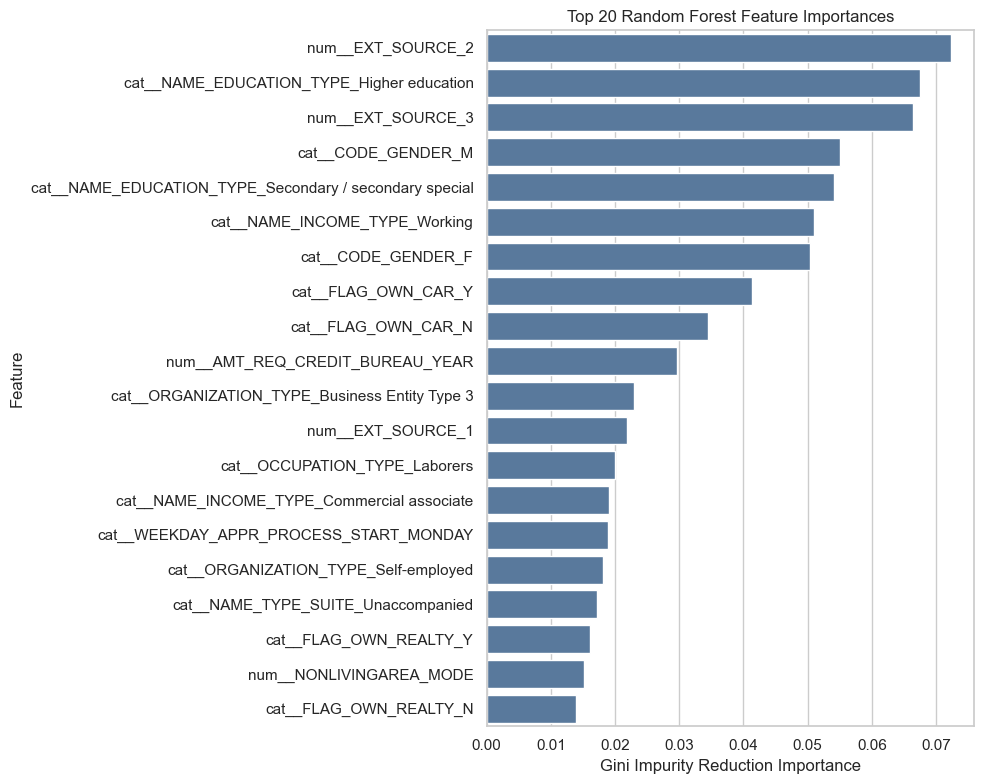

In [47]:
# extract transformed feature names from the fitted preprocessor
feature_names = random_forest_pipeline.named_steps["preprocessor"].get_feature_names_out()

# extract built-in random forest feature importances
rf_importances = pd.DataFrame(
    {
        "feature": feature_names,
        "importance": random_forest_pipeline.named_steps["model"].feature_importances_,
    }
).sort_values("importance", ascending=False)

print("Top 20 Random Forest Feature Importances")
display(rf_importances.head(20))

# plot top random forest feature importances
plt.figure(figsize=(10, 8))
sns.barplot(data=rf_importances.head(20), x="importance", y="feature", color="#4e79a7")
plt.title("Top 20 Random Forest Feature Importances")
plt.xlabel("Gini Impurity Reduction Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### RandomForest Interpretability

`RandomForest` is also providing a first layer of interpretability through feature importance scores. These scores are showing which variables contributed most strongly to prediction performance across all `200` decision trees.

Feature importance is helping identify which borrower characteristics were most useful for separating default and non-default cases. This provides insight into the model’s decision-making process and highlights the variables that are contributing the most predictive value.